# 📝 EDA – Inspect Raw Resume & Job Description Text

This notebook loads PDF resumes and job descriptions, extracts raw text, and performs **initial exploratory data analysis**, focusing on **noise, structure, missing sections, formatting, and token patterns**.

The goal is to **understand what kind of cleaning we will need later**.

---

## 🎯 Objectives

✔ Load dataset PDFs  
✔ Extract raw text  
✔ Preview random samples  
✔ Identify common noise  
✔ Check text length  
✔ Detect unusual tokens  
✔ Decide cleaning rules  

---

In [1]:
# 📦 Imports

import os
import random
from pathlib import Path
from pdfminer.high_level import extract_text
import matplotlib.pyplot as plt
import seaborn as sns

# 📂 Locate Dataset

Update the paths as required depending on your project structure.


In [14]:
DATASET_RESUME_DIR = Path("../../dataset/raw/dataset_noisy_pdfs/resumes_pdf")
DATASET_JD_DIR = Path("../../dataset/raw/dataset_noisy_pdfs/jds_pdf")

print("Resume files:", len(list(DATASET_RESUME_DIR.glob("*.pdf"))))
print("JD files:", len(list(DATASET_JD_DIR.glob("*.pdf"))))

Resume files: 200
JD files: 500


# 📄 PDF → Raw Text Extraction Function

In [15]:
def extract_pdf_text(pdf_path):
    try:
        return extract_text(pdf_path)
    except:
        return ""

# 🔍 Inspect a random resume

In [4]:
sample_resume = random.choice(list(DATASET_RESUME_DIR.glob("*.pdf")))
sample_resume

WindowsPath('../../dataset/dataset_noisy_pdfs/resumes_pdf/resume_010.pdf')

In [5]:
raw_resume_text = extract_pdf_text(sample_resume)
raw_resume_text[:2000]   # show first part

'Kevin Mills\nEmail: james53@example.com  |  Phone: +91-8755022797\nSUMMARY:\nPublic feel first sell. Actt perform none beyond.\nPROJECTS:\n- Built a scalable automation tool leveraging PyTorch and Interpersonal Skills.\nSKILLS:\nPyTorch, Time Management, AWS, Mentorship, Interpersonal Skills, Vue.js\nEXPERIENCE:\nSoil scientist at Wagne\nr and Sons (2017 - 2020)\n- Tested using Interpersonal Skills to improve memoory usage.\nMagazine journalist at\nSuarez LLC (2015 - 2020)\nfeel coach left these of score\n- Refactored using Time Management to improve memory usage.\nEDUCATION:\nB.Tech in Computer Science, 2014\n\n\x0c'

# 🔍 Inspect a random Job Description

In [6]:
sample_jd = random.choice(list(DATASET_JD_DIR.glob("*.pdf")))
sample_jd

WindowsPath('../../dataset/dataset_noisy_pdfs/jds_pdf/jd_184.pdf')

In [7]:
raw_jd_text = extract_pdf_text(sample_jd)
raw_jd_text[:2000]

'NOTE: Today whether thought.\nSoftware Engineer (Lead)\nLocation: Chennai\nRESPONSIBILITIES:\n· Bill have reality adult state medical. using React\n(cid:127) Oil ask eye off various research laugh effort southern idea iur of wall. using React\n* Short of heart sister fast need painting outside role question wonder. using Python\nﬁ Bed mission certain situation often PM notice chair north family sign. ©\n* Notice society task well three boaard stuff southern development.\n* Simply involve nor whether area performance age\n-> List huge brother shake win air kind see finally wall right mind determine.\nREQUIRED SKILLS:\nNode.js | Python | React | Microservices | Java | Docker\nNICE TO HAVE:\nPyTorch | Jira | Spring Boot | RabbitMQ\nApply at: https://www.taylor.com/\n\n\x0c'

# 📊 Text Length Statistics (how long are resumes?)

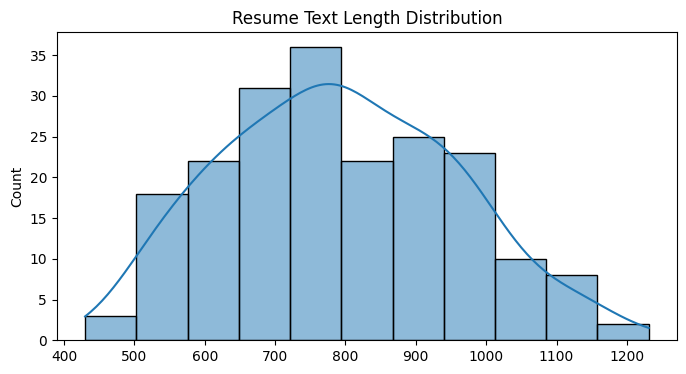

[983, 676, 746, 972, 865, 954, 626, 906, 1019, 602]

In [8]:
resume_lengths = []
for f in DATASET_RESUME_DIR.glob("*.pdf"):
    text = extract_pdf_text(f)
    resume_lengths.append(len(text))

plt.figure(figsize=(8,4))
sns.histplot(resume_lengths, kde=True)
plt.title("Resume Text Length Distribution")
plt.show()

resume_lengths[:10]

# 📊 Text Length Statistics (JDs)

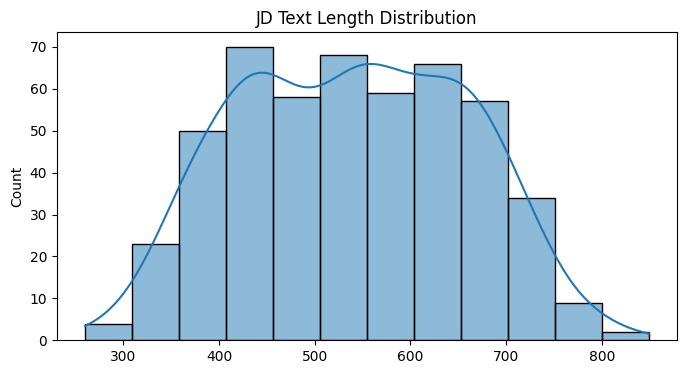

In [9]:
jd_lengths = []
for f in DATASET_JD_DIR.glob("*.pdf"):
    text = extract_pdf_text(f)
    jd_lengths.append(len(text))

plt.figure(figsize=(8,4))
sns.histplot(jd_lengths, kde=True)
plt.title("JD Text Length Distribution")
plt.show()

# 🧠 Check Common Noise Characters

We inspect suspicious symbols that usually appear due to extraction issues.

In [11]:
noisy_chars = ['\n', '\t', '●', '•', '■', '●', '©', '®', '–', '—']

for nc in noisy_chars:
    print(nc, "count:", raw_resume_text.count(nc))


 count: 19
	 count: 0
● count: 0
• count: 0
■ count: 0
● count: 0
© count: 0
® count: 0
– count: 0
— count: 0


# 🧹 Find frequently occurring weird characters

In [12]:
import collections
freq_chars = collections.Counter(raw_resume_text)
freq_chars.most_common(20)

[(' ', 70),
 ('e', 52),
 ('o', 30),
 ('n', 29),
 ('a', 29),
 ('l', 26),
 ('i', 25),
 ('t', 25),
 ('s', 24),
 ('r', 23),
 ('\n', 19),
 ('m', 17),
 ('c', 14),
 ('S', 12),
 ('u', 11),
 ('g', 10),
 ('p', 9),
 ('2', 9),
 ('.', 8),
 ('0', 8)]

# 🔠 Check uppercase ratios (to detect headers, shouting text etc.)

In [13]:
def uppercase_ratio(text):
    if not text: return 0
    uppercase = sum(c.isupper() for c in text)
    return uppercase / len(text)

uppercase_ratio(raw_resume_text), uppercase_ratio(raw_jd_text)

(0.132890365448505, 0.1013157894736842)

# 📌 Observations & Cleaning Plan (write your notes here)

### Noise Found
- bullet characters
- random unicode
- extra newline
- tabs
- broken spacing

### Required Cleaning
- remove extra spaces
- normalize unicode
- remove bullet unicode
- convert fancy hyphens to normal hyphens
- fix weird line breaks

# 🏁 Summary

In this notebook, we:

✔ loaded raw PDFs  
✔ extracted text  
✔ observed noise  
✔ visualized length distribution  
✔ discovered cleaning needs  